In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, LinearRegression , Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
    QuantileTransformer,
)

from joblib import dump

from src.config import DADOS_LIMPOS , MODELO_FINAL
from src.auxiliares import dataframe_coeficientes
from src.graficos import (
    plot_coeficientes,
    plot_comparar_metricas_modelos,
    plot_residuos_estimador,
)
from src.models import (
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    grid_search_cv_regressor,
)

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
X = df.drop(columns = ['math score'])
y = df['math score']

In [5]:
colunas_one_hot_encoder = ['gender' , 'race/ethnicity' , 'parental level of education' , 'lunch' , 'test preparation course']

colunas_standard_scaler = ["reading score","writing score"]


In [6]:
preprocessamento = ColumnTransformer(
    transformers = [
        ('one_hot' , OneHotEncoder(drop = 'if_binary') , colunas_one_hot_encoder),
        ('standard_escaler' , StandardScaler() , colunas_standard_scaler),
    ],
     remainder="passthrough",
)

In [7]:
elastic_net = ElasticNet()

In [8]:
param_grid = {
    "reg__alpha": [1E-2, 5E-2, 0.1, 1.0, 5.0, 10],
    "reg__l1_ratio" : [0.1,0.25,0.5,0.75,0.9],
}

In [9]:
grid_search = grid_search_cv_regressor(
    regressor = elastic_net,
    param_grid = param_grid,
    preprocessor = preprocessamento,
    target_transformer = None 
)

grid_search

,estimator,Pipeline(step...lasticNet())])
,param_grid,"{'reg__alpha': [0.01, 0.05, ...], 'reg__l1_ratio': [0.1, 0.25, ...]}"
,scoring,"['r2', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('one_hot', ...), ('standard_escaler', ...)]"


In [10]:
grid_search.fit(X,y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...lasticNet())])
,param_grid,"{'reg__alpha': [0.01, 0.05, ...], 'reg__l1_ratio': [0.1, 0.25, ...]}"
,scoring,"['r2', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('one_hot', ...), ('standard_escaler', ...)]"


In [11]:
grid_search.best_params_

{'reg__alpha': 0.01, 'reg__l1_ratio': 0.9}

In [12]:
grid_search.best_score_

np.float64(-5.407657710273468)

In [13]:
grid_search.best_estimator_

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('one_hot', ...), ('standard_escaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
print(*grid_search.cv_results_.keys(), sep = "\n")

mean_fit_time
std_fit_time
mean_score_time
std_score_time
param_reg__alpha
param_reg__l1_ratio
params
split0_test_r2
split1_test_r2
split2_test_r2
split3_test_r2
split4_test_r2
mean_test_r2
std_test_r2
rank_test_r2
split0_test_neg_mean_absolute_error
split1_test_neg_mean_absolute_error
split2_test_neg_mean_absolute_error
split3_test_neg_mean_absolute_error
split4_test_neg_mean_absolute_error
mean_test_neg_mean_absolute_error
std_test_neg_mean_absolute_error
rank_test_neg_mean_absolute_error
split0_test_neg_root_mean_squared_error
split1_test_neg_root_mean_squared_error
split2_test_neg_root_mean_squared_error
split3_test_neg_root_mean_squared_error
split4_test_neg_root_mean_squared_error
mean_test_neg_root_mean_squared_error
std_test_neg_root_mean_squared_error
rank_test_neg_root_mean_squared_error


In [15]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },
    "LinearRegression_pre_simples": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None,
    },
    "elastic_net_grid_cv": {
    "preprocessor": grid_search.best_estimator_.named_steps["preprocessor"],
    "regressor": grid_search.best_estimator_.named_steps["reg"],
    "target_transformer": None,
    }
}

In [16]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

In [17]:
resultados

{'DummyRegressor': {'fit_time': array([0.01170635, 0.00635672, 0.00480795, 0.00717235, 0.00523472]),
  'score_time': array([0.00866747, 0.01108694, 0.00668073, 0.00845671, 0.00782704]),
  'test_r2': array([-1.70392920e-02, -2.07746859e-05, -1.00269466e-03, -1.47565145e-02,
         -1.85118676e-03]),
  'test_neg_mean_absolute_error': array([-12.33985 , -12.24725 , -12.221025, -11.8817  , -11.463875]),
  'test_neg_root_mean_squared_error': array([-15.7316469 , -15.35802315, -14.9686452 , -14.9369877 ,
         -14.85960974])},
 'LinearRegression_pre_simples': {'fit_time': array([0.17436314, 0.04581451, 0.04374433, 0.04471278, 0.04500866]),
  'score_time': array([0.02896476, 0.0284934 , 0.02842593, 0.02825785, 0.02873206]),
  'test_r2': array([0.8804333 , 0.86165874, 0.8810633 , 0.85567747, 0.87963568]),
  'test_neg_mean_absolute_error': array([-4.21476314, -4.6301703 , -4.08585975, -4.52414388, -4.11546872]),
  'test_neg_root_mean_squared_error': array([-5.39399387, -5.71224302, -5.1596

In [18]:
df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.011706,0.008667,-0.017039,-12.33985,-15.731647,0.020374
1,DummyRegressor,0.006357,0.011087,-0.000021,-12.24725,-15.358023,0.017444
2,DummyRegressor,0.004808,0.006681,-0.001003,-12.221025,-14.968645,0.011489
3,DummyRegressor,0.007172,0.008457,-0.014757,-11.8817,-14.936988,0.015629
4,DummyRegressor,0.005235,0.007827,-0.001851,-11.463875,-14.85961,0.013062
5,LinearRegression_pre_simples,0.174363,0.028965,0.880433,-4.214763,-5.393994,0.203328
6,LinearRegression_pre_simples,0.045815,0.028493,0.861659,-4.63017,-5.712243,0.074308
7,LinearRegression_pre_simples,0.043744,0.028426,0.881063,-4.08586,-5.159681,0.07217
8,LinearRegression_pre_simples,0.044713,0.028258,0.855677,-4.524144,-5.633122,0.072971
9,LinearRegression_pre_simples,0.045009,0.028732,0.879636,-4.115469,-5.150563,0.073741


In [19]:
df_resultados['model_group'] = df_resultados['model'].str.split("_").str[0]

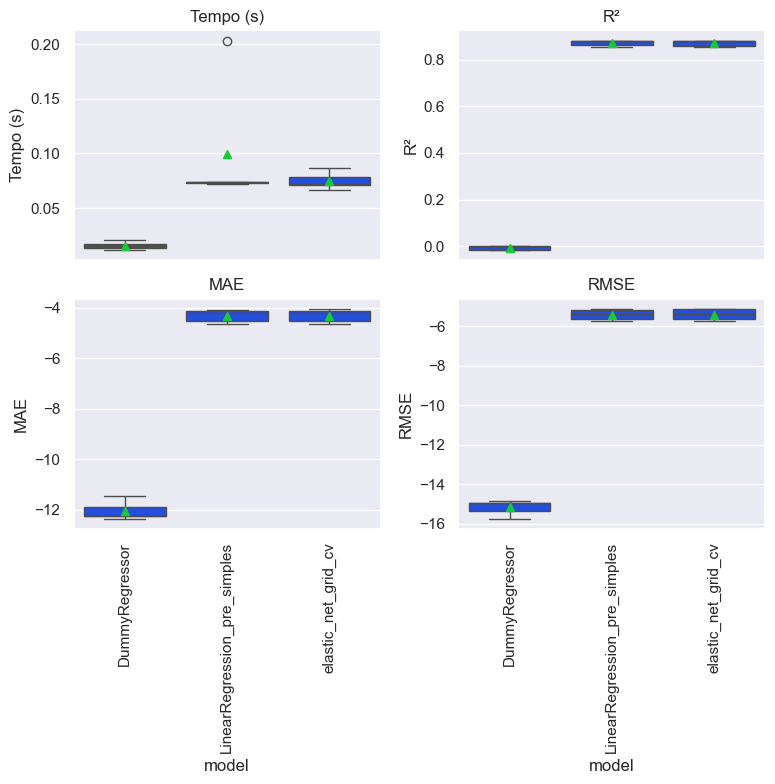

In [20]:
plot_comparar_metricas_modelos(df_resultados)

In [21]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\tiago\\Documents\\DATA SCIENCE\\PROJETOS\\Projetos Regressão\\Project_students_perfomance\\modelos\\students_perfomance_model.jolib']